# PINN: Trajektorie lernen → danach Wurf klassifizieren (clean & noisy)

Zielsetzung:
- Das PINN lernt die Trajektorie \((x(t), y(t))\) aus Eingaben `[theta, v0, hs, t]`.
- Nach dem Training wird jede vorausgesagte Trajektorie deterministisch klassifiziert zu.
- Auswertung: Loss-Kurven, Beispieltrajektorien (Datensatz vs. Vorhersage), wurfweise Konfusionsmatrix & Metriken.

Klassifikations-Heuristik aus der vorhergesagten Trajektorie:
Beurteilt den Wurf am Korb-Plane `x = l`. Falls `max(x_pred) < l`, gilt zu kurz. Ansonsten wird `y_pred` bei `x=l` linear interpoliert. Liegt der Ballmittelpunkt im Fenster `[hKorb - (Rr - Rb), hKorb + (Rr - Rb)]`, werten wir als Treffer, sonst zu lang.


In [1]:
import os, sys, time, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
print('Python', sys.version)
print('Torch', torch.__version__)


Python 3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]
Torch 2.6.0+cpu


In [2]:
class DataGen:
    def __init__(self, hs=2.13, l=4.115, hKorb=3.048, Rr=0.2286, Rb=0.1219, g=9.807):
        self.params = {'l': l, 'hKorb': hKorb, 'Rr': Rr, 'Rb': Rb, 'g': g}
        self.hs = hs
        self.wurf_hoehe = 1.25 * hs
    def wurfgeschwindigkeit(self, theta):
        l = self.params['l']; h = self.params['hKorb'] - self.wurf_hoehe; g = self.params['g']
        return (l/np.cos(theta)) * np.sqrt(g / (2 * (l*np.tan(theta) - h)))
    def wurftrajektorien(self, theta, v0, t):
        g = self.params['g']; vx = v0*np.cos(theta); vy = v0*np.sin(theta)
        x = vx * t; y = vy * t - 0.5 * g * t**2 + self.wurf_hoehe
        return x, y
    def generate_dataset(self, base_theta_deg=48.43, n=150, with_noise=False):
        base_theta = np.deg2rad(base_theta_deg); base_v0 = self.wurfgeschwindigkeit(base_theta)
        cats = {0:{'theta':(-0.15,-0.05),'v0':(-0.5,-0.2)}, 1:{'theta':(-0.03,0.03),'v0':(-0.1,0.1)}, 2:{'theta':(0.06,0.15),'v0':(0.3,0.5)}}
        rows=[]
        for label,var in cats.items():
            rows += self._gen(base_theta, base_v0, var, label, n)
        df = pd.DataFrame(rows)
        if with_noise:
            df = self.full_noise_pipeline(df)
        return df
    def _gen(self, theta_base, v0_base, var, label, n):
        g = self.params['g']; rows=[]
        for _ in range(n):
            theta = theta_base + np.random.uniform(*var['theta'])
            v0 = v0_base + np.random.uniform(*var['v0'])
            T = 2 * v0 * np.sin(theta) / g
            t_vals = np.linspace(0, T, 50)
            x, y = self.wurftrajektorien(theta, v0, t_vals)
            wid = str(np.random.randint(1e9))
            for xi, yi, ti in zip(x, y, t_vals):
                rows.append({'x':xi,'y':yi,'theta':theta,'v0':v0,'t':ti,'label':label,'wurf_id':wid})
        return rows
    def add_position_noise(self, df, std_x=0.1, std_y=0.1):
        d = df.copy(); d['x'] += np.random.normal(0,std_x,len(df)); d['y'] += np.random.normal(0,std_y,len(df)); return d
    def full_noise_pipeline(self, df):
        return self.add_position_noise(df)


In [3]:
class FreeThrowPINNModel(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, 2)
        )
    def forward(self, theta, v0, hs, t):
        if theta.dim()==1: theta = theta.unsqueeze(1)
        if v0.dim()==1: v0 = v0.unsqueeze(1)
        if hs.dim()==1: hs = hs.unsqueeze(1)
        if t.dim()==1: t = t.unsqueeze(1)
        inp = torch.cat([theta, v0, hs, t], dim=1)
        out = self.net(inp)
        return out[:,0:1], out[:,1:2]

def df_to_tensors(df, hs_val=2.13, device='cpu'):
    d = df.copy()
    if 't' not in d.columns:
        d['vx'] = d['v0'] * np.cos(d['theta']).astype(float)
        d['vx'] = d['vx'].replace(0, 1e-8)
        d['t'] = d['x']/d['vx']
    d['t'] = d['t'].clip(lower=0.0)
    d['hs'] = hs_val
    d = d.dropna(subset=['theta','v0','t','x','y','label','wurf_id'])
    theta = torch.tensor(d['theta'].values, dtype=torch.float32, device=device).unsqueeze(1)
    v0    = torch.tensor(d['v0'].values,    dtype=torch.float32, device=device).unsqueeze(1)
    hs    = torch.tensor(d['hs'].values,    dtype=torch.float32, device=device).unsqueeze(1)
    t     = torch.tensor(d['t'].values,     dtype=torch.float32, device=device).unsqueeze(1)
    x     = torch.tensor(d['x'].values,     dtype=torch.float32, device=device).unsqueeze(1)
    y     = torch.tensor(d['y'].values,     dtype=torch.float32, device=device).unsqueeze(1)
    return theta, v0, hs, t, x, y, d


In [4]:
def physics_residuals(model, theta, v0, hs, t, g=9.807):
    t_req = t.clone().detach().requires_grad_(True)
    th = theta.detach(); v = v0.detach(); h = hs.detach()
    x_pred, y_pred = model(th, v, h, t_req)
    dx_dt = torch.autograd.grad(x_pred, t_req, grad_outputs=torch.ones_like(x_pred), create_graph=True)[0]
    dy_dt = torch.autograd.grad(y_pred, t_req, grad_outputs=torch.ones_like(y_pred), create_graph=True)[0]
    return dx_dt - v * torch.cos(th), dy_dt - (v * torch.sin(th) - g * t_req)

def train_pinn(model, df, n_epochs=200, batch_size=1024, lr=1e-3, lambda_data=1, lambda_phys=1, device='cpu'):
    device = torch.device(device)
    theta,v0,hs,t,x_true,y_true,dproc = df_to_tensors(df, hs_val=2.13, device=device)
    ds = TensorDataset(theta,v0,hs,t,x_true,y_true)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True)
    opt = optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()
    hist = {'loss':[], 'data_loss':[], 'phys_loss':[]}
    for ep in range(1, n_epochs+1):
        ep_loss=ep_data=ep_phys=0.0; N=0
        model.train()
        for b in dl:
            b_theta,b_v0,b_hs,b_t,b_x,b_y = [bi.to(device) for bi in b]
            opt.zero_grad()
            b_t = b_t.clone().detach().requires_grad_(True)
            x_pred, y_pred = model(b_theta,b_v0,b_hs,b_t)
            data_loss = mse(x_pred,b_x) + mse(y_pred,b_y)
            try:
                rx, ry = physics_residuals(model,b_theta,b_v0,b_hs,b_t)
                phys_loss = rx.pow(2).mean() + ry.pow(2).mean()
            except RuntimeError:
                phys_loss = torch.tensor(0.0, device=device)
            loss = lambda_data*data_loss + lambda_phys*phys_loss
            loss.backward(); opt.step()
            bs=b_theta.size(0)
            ep_loss += loss.item()*bs; ep_data += data_loss.item()*bs; ep_phys += phys_loss.item()*bs; N+=bs
        hist['loss'].append(ep_loss/N); hist['data_loss'].append(ep_data/N); hist['phys_loss'].append(ep_phys/N)
        if ep % max(1, n_epochs//10) == 0 or ep<=5:
            print(f"Epoch {ep:03d} | loss={hist['loss'][-1]:.6f} (data={hist['data_loss'][-1]:.6f}, phys={hist['phys_loss'][-1]:.6f})")
    return model, hist, dproc


In [5]:
def predict_xy(model, dproc, hs_val=2.13):
    model.eval()
    with torch.no_grad():
        th = torch.tensor(dproc['theta'].values, dtype=torch.float32).unsqueeze(1)
        v0 = torch.tensor(dproc['v0'].values, dtype=torch.float32).unsqueeze(1)
        hs = torch.tensor(np.full_like(dproc['v0'].values, hs_val, dtype=np.float32)).unsqueeze(1)
        tt = torch.tensor(dproc['t'].values, dtype=torch.float32).unsqueeze(1)
        x_pred, y_pred = model(th, v0, hs, tt)
    out = dproc.copy()
    out['x_pred'] = x_pred.cpu().numpy().flatten()
    out['y_pred'] = y_pred.cpu().numpy().flatten()
    return out

def classify_wurf_from_prediction(df_wurf, l, hKorb, Rr, Rb, eps=1e-3):
    g = df_wurf.sort_values('x_pred')
    if g['x_pred'].max() < l - eps:
        return 0
    before = g[g['x_pred'] <= l]
    after  = g[g['x_pred'] >= l]
    if before.empty or after.empty:
        idx = (g['x_pred']-l).abs().idxmin()
        y_at_l = g.loc[idx, 'y_pred']
    else:
        i1 = before.index[-1]; i2 = after.index[0]
        x1,y1 = g.loc[i1,'x_pred'], g.loc[i1,'y_pred']
        x2,y2 = g.loc[i2,'x_pred'], g.loc[i2,'y_pred']
        if abs(x2-x1) < 1e-8:
            y_at_l = y1
        else:
            w = (l - x1) / (x2 - x1)
            y_at_l = y1 + w*(y2 - y1)
    win_lo = hKorb - (Rr - Rb)
    win_hi = hKorb + (Rr - Rb)
    return 1 if (win_lo <= y_at_l <= win_hi) else 2

def evaluate_throw_level(pred_df, params):
    l, hK, Rr, Rb = params['l'], params['hKorb'], params['Rr'], params['Rb']
    true_labels = pred_df.groupby('wurf_id')['label'].first()
    pred_labels = pred_df.groupby('wurf_id').apply(lambda g: classify_wurf_from_prediction(g, l, hK, Rr, Rb))
    y_true = true_labels.values; y_pred = pred_labels.values
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return {'cm':cm, 'acc':acc, 'prec':prec, 'rec':rec, 'f1':f1, 'y_true':y_true, 'y_pred':y_pred}


## Clean‑Training (Trajektorie) → Wurfklassifikation aus Vorhersage

Epoch 001 | loss=35.862167 (data=8.534322, phys=27.327845)
Epoch 002 | loss=26.297358 (data=1.721411, phys=24.575947)
Epoch 003 | loss=12.007634 (data=1.154865, phys=10.852769)
Epoch 004 | loss=3.006842 (data=0.412538, phys=2.594304)
Epoch 005 | loss=0.841941 (data=0.210915, phys=0.631026)
Epoch 020 | loss=0.101558 (data=0.039139, phys=0.062418)
Epoch 040 | loss=0.031725 (data=0.007716, phys=0.024009)
Epoch 060 | loss=0.016791 (data=0.004337, phys=0.012454)
Epoch 080 | loss=0.011790 (data=0.003332, phys=0.008459)
Epoch 100 | loss=0.009670 (data=0.003057, phys=0.006613)
Epoch 120 | loss=0.007302 (data=0.002512, phys=0.004789)
Epoch 140 | loss=0.005058 (data=0.001761, phys=0.003298)
Epoch 160 | loss=0.003219 (data=0.001197, phys=0.002022)
Epoch 180 | loss=0.002673 (data=0.001089, phys=0.001584)
Epoch 200 | loss=0.004286 (data=0.001503, phys=0.002783)


C:\Users\luca1\AppData\Local\Temp\ipykernel_11448\2127963107.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pred_labels = pred_df.groupby('wurf_id').apply(lambda g: classify_wurf_from_prediction(g, l, hK, Rr, Rb))


Clean throw-level metrics:
Accuracy= 0.8111111111111111  Precision= 0.8794326241134751  Recall= 0.8111111111111112  F1= 0.8148223161370319


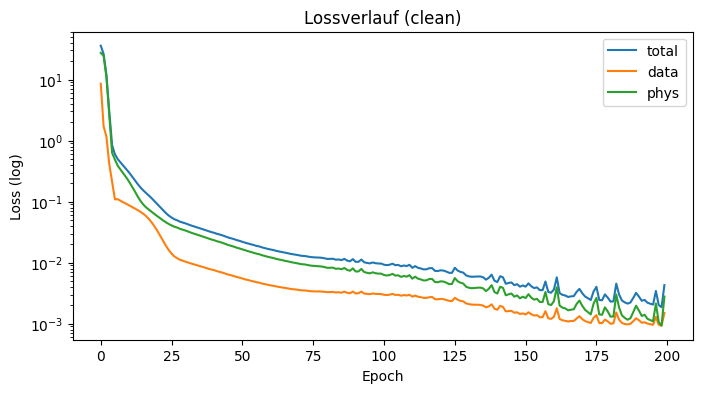

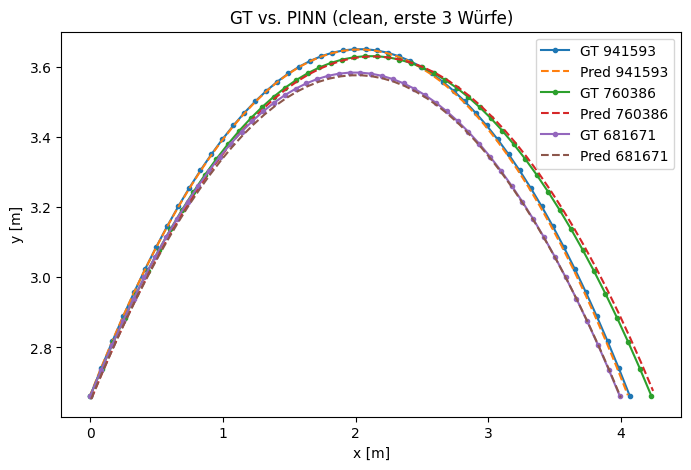

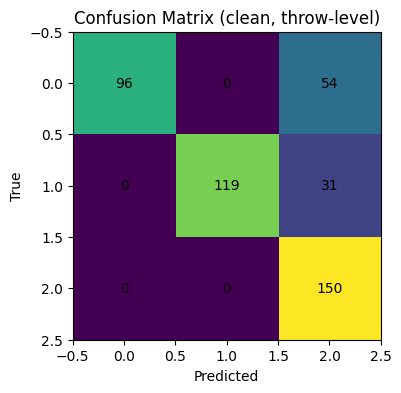

In [6]:
device='cpu'
sim = DataGen(hs=2.13)
params = sim.params if hasattr(sim,'params') else {'l':4.115,'hKorb':3.048,'Rr':0.2286,'Rb':0.1219}
df_clean = sim.generate_dataset(n=150, with_noise=False)
model_clean = FreeThrowPINNModel(hidden_dim=64).to(device)
model_clean, hist_clean, dproc_clean = train_pinn(model_clean, df_clean, n_epochs=200, batch_size=1024, lr=1e-3, lambda_data=1.0, lambda_phys=1.0, device=device)

plt.figure(figsize=(8,4))
plt.plot(hist_clean['loss'], label='total')
plt.plot(hist_clean['data_loss'], label='data')
plt.plot(hist_clean['phys_loss'], label='phys')
plt.yscale('log'); plt.xlabel('Epoch'); plt.ylabel('Loss (log)'); plt.legend(); plt.title('Lossverlauf (clean)')

pred_clean = predict_xy(model_clean, dproc_clean)
ids = pred_clean['wurf_id'].unique()[:3]
plt.figure(figsize=(8,5))
for wid in ids:
    g_gt = dproc_clean[dproc_clean['wurf_id']==wid].sort_values('t')
    g_pr = pred_clean[pred_clean['wurf_id']==wid].sort_values('t')
    plt.plot(g_gt['x'], g_gt['y'], marker='.', label=f'GT {wid[:6]}')
    plt.plot(g_pr['x_pred'], g_pr['y_pred'], linestyle='--', label=f'Pred {wid[:6]}')
plt.xlabel('x [m]'); plt.ylabel('y [m]'); plt.title('GT vs. PINN (clean, erste 3 Würfe)'); plt.legend()

eval_clean = evaluate_throw_level(pred_clean, params)
print('Clean throw-level metrics:')
print('Accuracy=', eval_clean['acc'], ' Precision=', eval_clean['prec'], ' Recall=', eval_clean['rec'], ' F1=', eval_clean['f1'])
cm = eval_clean['cm']
plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title('Confusion Matrix (clean, throw-level)')
plt.xlabel('Predicted'); plt.ylabel('True')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha='center', va='center')


## Noisy‑Training (Trajektorie) → Wurfklassifikation aus Vorhersage

Epoch 001 | loss=36.082399 (data=8.599850, phys=27.482549)
Epoch 002 | loss=26.988828 (data=1.780394, phys=25.208434)
Epoch 003 | loss=14.983367 (data=1.109855, phys=13.873513)
Epoch 004 | loss=4.346871 (data=0.411716, phys=3.935155)
Epoch 005 | loss=1.316890 (data=0.277545, phys=1.039345)
Epoch 020 | loss=0.074830 (data=0.032309, phys=0.042521)
Epoch 040 | loss=0.042007 (data=0.025377, phys=0.016631)
Epoch 060 | loss=0.033048 (data=0.023430, phys=0.009617)
Epoch 080 | loss=0.029671 (data=0.022934, phys=0.006737)
Epoch 100 | loss=0.027884 (data=0.022575, phys=0.005309)
Epoch 120 | loss=0.025984 (data=0.021968, phys=0.004016)
Epoch 140 | loss=0.024755 (data=0.021490, phys=0.003265)
Epoch 160 | loss=0.022916 (data=0.021023, phys=0.001893)
Epoch 180 | loss=0.022418 (data=0.020867, phys=0.001551)
Epoch 200 | loss=0.022356 (data=0.020867, phys=0.001489)


C:\Users\luca1\AppData\Local\Temp\ipykernel_11448\2127963107.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pred_labels = pred_df.groupby('wurf_id').apply(lambda g: classify_wurf_from_prediction(g, l, hK, Rr, Rb))


Noisy throw-level metrics:
Accuracy= 0.8111111111111111  Precision= 0.8794326241134751  Recall= 0.8111111111111112  F1= 0.8142338374629222
Vergleich (wurf-level):
     set       acc      prec       rec        f1
0  clean  0.811111  0.879433  0.811111  0.814822
1  noisy  0.811111  0.879433  0.811111  0.814234


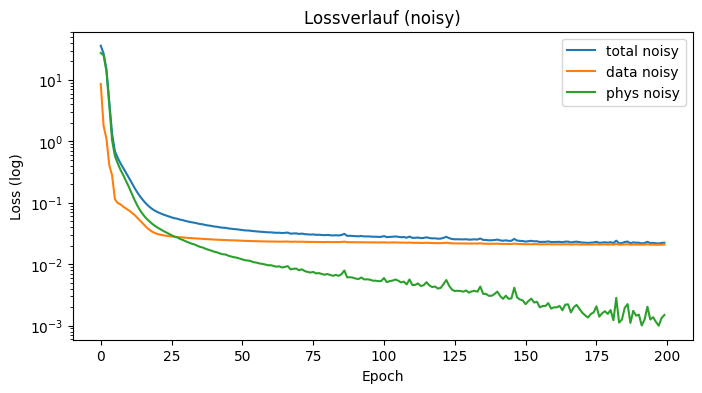

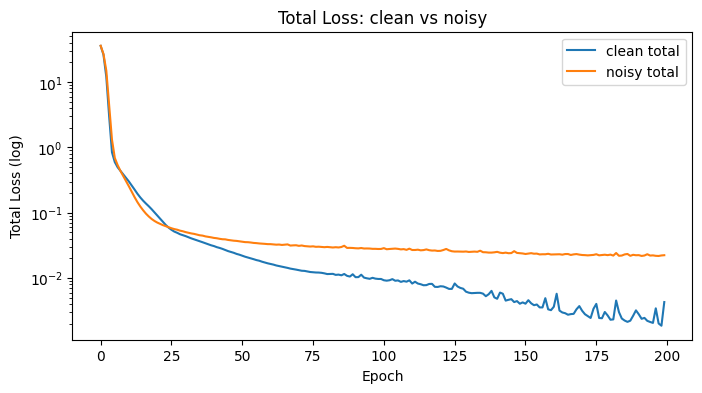

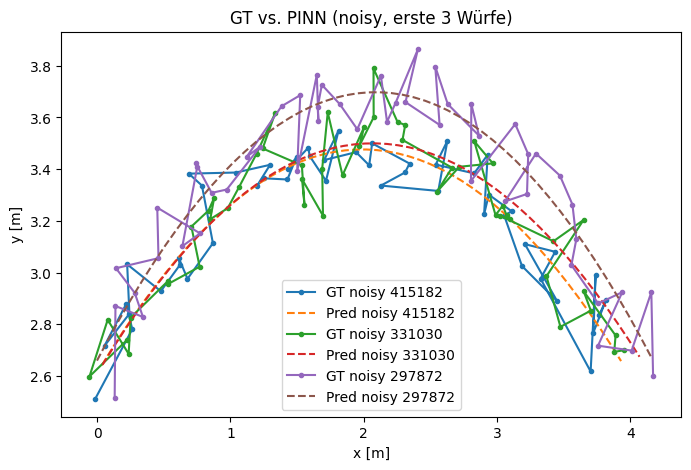

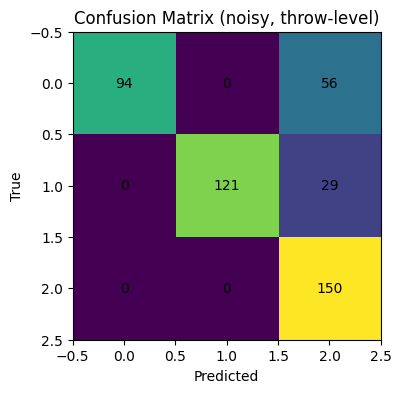

In [7]:
df_noisy = sim.generate_dataset(n=150, with_noise=True)
model_noisy = FreeThrowPINNModel(hidden_dim=64).to(device)
model_noisy, hist_noisy, dproc_noisy = train_pinn(model_noisy, df_noisy, n_epochs=200, batch_size=1024, lr=1e-3, lambda_data=1, lambda_phys=1, device=device)

plt.figure(figsize=(8,4))
plt.plot(hist_noisy['loss'], label='total noisy')
plt.plot(hist_noisy['data_loss'], label='data noisy')
plt.plot(hist_noisy['phys_loss'], label='phys noisy')
plt.yscale('log'); plt.xlabel('Epoch'); plt.ylabel('Loss (log)'); plt.legend(); plt.title('Lossverlauf (noisy)')

plt.figure(figsize=(8,4))
plt.plot(hist_clean['loss'], label='clean total')
plt.plot(hist_noisy['loss'], label='noisy total')
plt.yscale('log'); plt.xlabel('Epoch'); plt.ylabel('Total Loss (log)'); plt.legend(); plt.title('Total Loss: clean vs noisy')

pred_noisy = predict_xy(model_noisy, dproc_noisy)
ids2 = pred_noisy['wurf_id'].unique()[:3]
plt.figure(figsize=(8,5))
for wid in ids2:
    g_gt = dproc_noisy[dproc_noisy['wurf_id']==wid].sort_values('t')
    g_pr = pred_noisy[pred_noisy['wurf_id']==wid].sort_values('t')
    plt.plot(g_gt['x'], g_gt['y'], marker='.', label=f'GT noisy {wid[:6]}')
    plt.plot(g_pr['x_pred'], g_pr['y_pred'], linestyle='--', label=f'Pred noisy {wid[:6]}')
plt.xlabel('x [m]'); plt.ylabel('y [m]'); plt.title('GT vs. PINN (noisy, erste 3 Würfe)'); plt.legend()

eval_noisy = evaluate_throw_level(pred_noisy, params)
print('Noisy throw-level metrics:')
print('Accuracy=', eval_noisy['acc'], ' Precision=', eval_noisy['prec'], ' Recall=', eval_noisy['rec'], ' F1=', eval_noisy['f1'])
cmn = eval_noisy['cm']
plt.figure(figsize=(5,4))
plt.imshow(cmn)
plt.title('Confusion Matrix (noisy, throw-level)')
plt.xlabel('Predicted'); plt.ylabel('True')
for i in range(cmn.shape[0]):
    for j in range(cmn.shape[1]):
        plt.text(j, i, cmn[i,j], ha='center', va='center')

comp = pd.DataFrame([
    {'set':'clean','acc':eval_clean['acc'],'prec':eval_clean['prec'],'rec':eval_clean['rec'],'f1':eval_clean['f1']},
    {'set':'noisy','acc':eval_noisy['acc'],'prec':eval_noisy['prec'],'rec':eval_noisy['rec'],'f1':eval_noisy['f1']},
])
print('Vergleich (wurf-level):')
print(comp)


In [25]:
# Split-Logik: erste 30 Punkte vs. volle 50 Punkte pro Wurf ===============================

from typing import Tuple, Dict


def add_point_index(df: pd.DataFrame) -> pd.DataFrame:
    """Fügt pro wurf_id einen 1-basierten Punktindex hinzu (nach Zeit sortiert)."""
    assert "wurf_id" in df.columns, "Erwarte Spalte 'wurf_id'."
    # Sortierung: falls 't' existiert, danach sortieren; sonst x/vx Heuristik vermeiden -> fallback: index
    if "t" in df.columns:
        df = df.sort_values(["wurf_id", "t"]).copy()
    else:
        df = df.sort_values(["wurf_id"]).copy()
    df["point_idx"] = df.groupby("wurf_id").cumcount() + 1
    return df


def split_first30_full50(
    df: pd.DataFrame, first_n: int = 30
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Gibt (df_train30, df_full50) zurück.
    df_train30 enthält nur die ersten N Punkte pro Wurf.
    df_full50 enthält alle verfügbaren Punkte (typisch 50).
    """
    dfi = add_point_index(df)
    df_train30 = dfi[dfi["point_idx"] <= first_n].copy()
    df_full50 = dfi.copy()
    return df_train30, df_full50

In [ ]:
# Vorhersage für die volle Domain 1–50 ====================================================


def predict_full50(
    model: nn.Module, df_all: pd.DataFrame, hs_val: float, device: str = "cpu"
) -> pd.DataFrame:
    """
    Nutzt dein vorhandenes predict_xy() und liefert ein DataFrame mit x_pred/y_pred für ALLE 50 Punkte.
    Erwartet, dass predict_xy intern df_to_tensors nutzt und hs korrekt einbindet.
    """
    model.eval()
    with torch.no_grad():
        pred_df = predict_xy(model, df_all, hs_val=hs_val)
    return add_point_index(pred_df)

In [27]:
# Metriken In-Domain (1–30) vs. Out-of-Domain (31–50) ====================================


def mse_mae(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    mse = float(np.mean((y_true - y_pred) ** 2)) if len(y_true) > 0 else np.nan
    mae = float(np.mean(np.abs(y_true - y_pred))) if len(y_true) > 0 else np.nan
    return {"mse": mse, "mae": mae}


def evaluate_in_out_domain(pred_df: pd.DataFrame) -> Dict[str, Dict[str, float]]:
    """
    Erwartet Spalten: x, y, x_pred, y_pred, point_idx.
    Gibt MSE/MAE getrennt für 1–30, 31–50 und 1–50 zurück (sowohl für x als auch y).
    """
    required = {"x", "y", "x_pred", "y_pred", "point_idx"}
    missing = required - set(pred_df.columns)
    assert not missing, f"Fehlende Spalten: {missing}"

    df = pred_df.copy()
    in_mask = df["point_idx"] <= 30
    out_mask = df["point_idx"] > 30

    res = {
        "x_in": mse_mae(
            df.loc[in_mask, "x"].to_numpy(), df.loc[in_mask, "x_pred"].to_numpy()
        ),
        "x_out": mse_mae(
            df.loc[out_mask, "x"].to_numpy(), df.loc[out_mask, "x_pred"].to_numpy()
        ),
        "x_all": mse_mae(df["x"].to_numpy(), df["x_pred"].to_numpy()),
        "y_in": mse_mae(
            df.loc[in_mask, "y"].to_numpy(), df.loc[in_mask, "y_pred"].to_numpy()
        ),
        "y_out": mse_mae(
            df.loc[out_mask, "y"].to_numpy(), df.loc[out_mask, "y_pred"].to_numpy()
        ),
        "y_all": mse_mae(df["y"].to_numpy(), df["y_pred"].to_numpy()),
    }
    return res

In [28]:
# Klassifikation auf Basis der vollen 1–50-Vorhersage =====================================


def classify_full_trajectory(
    pred_full50_df: pd.DataFrame, params: dict
) -> pd.DataFrame:
    """
    Wendet deine bestehende wurfweise Klassifikation (zu kurz / Treffer / zu lang) an.
    Erwartet vorhandene Funktion: classify_wurf_from_prediction(df_wurf, l, hKorb, Rr, Rb)
    und Parameter z.B. in params = {'l':..., 'hKorb':..., 'Rr':..., 'Rb':...}
    """
    l = params["l"]
    hK = params["hKorb"]
    Rr = params["Rr"]
    Rb = params["Rb"]

    out = []
    for wid, df_w in pred_full50_df.groupby("wurf_id"):
        cls = classify_wurf_from_prediction(df_w, l, hK, Rr, Rb)
        out.append({"wurf_id": wid, "pred_class": int(cls)})
    return pd.DataFrame(out)

In [29]:
# Visualisierung: GT vs. Pred (1–50) mit Markierung bei Punkt 30 ==========================

import matplotlib.pyplot as plt


def plot_trajectories_with_cutoff(
    pred_full50_df: pd.DataFrame, wurf_ids=None, max_plots: int = 3
):
    """
    Plottet für ausgewählte Würfe die GT- und Pred-Trajektorie (x,y) und markiert den Cutoff bei point_idx=30.
    """
    if wurf_ids is None:
        wurf_ids = list(pred_full50_df["wurf_id"].unique())[:max_plots]

    for wid in wurf_ids[:max_plots]:
        dfw = pred_full50_df[pred_full50_df["wurf_id"] == wid].sort_values("point_idx")
        cutoff_x = (
            dfw.loc[dfw["point_idx"] == 30, "x"].iloc[0]
            if (dfw["point_idx"] == 30).any()
            else None
        )

        plt.figure(figsize=(5.5, 4.5))
        plt.plot(dfw["x"], dfw["y"], label="GT")
        plt.plot(dfw["x_pred"], dfw["y_pred"], label="Pred")
        if cutoff_x is not None:
            plt.axvline(cutoff_x, linestyle="--", label="Cutoff @ 30")
        plt.title(f"Wurf {wid}: GT vs. Pred (1–50)")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.legend()
        plt.tight_layout()
        plt.show()

In [31]:
# === CLEAN RUN ==================================================================================

# 1) Daten splitten (nur für das Training relevant — das volle DF brauchen wir später fürs Predict)
df_train30_clean, df_full50_clean = split_first30_full50(df_clean, first_n=30)
print(df_clean.shape, df_clean.head())
# 2) Modell initialisieren (wie in deinem Notebook)
model_clean = FreeThrowPINNModel()  # ggf. mit denselben Hidden-Dims/Init wie vorher
model_clean = model_clean.to(device)

# 3) Train nur auf den ersten 30 Punkten
model_clean, hist_clean, dproc_train30_clean = train_pinn(model_clean, df_train30_clean, n_epochs=200, batch_size=1024, lr=1e-3, lambda_data=1.0, lambda_phys=1.0, device=device)

# 4) Vorhersage für ALLE 1–50 Punkte
pred_full50_clean = predict_full50(
    model_clean, df_full50_clean, hs_val=2.13, device=device
)

# 5) Metriken In-Domain vs. Extrapolation
metrics_clean = evaluate_in_out_domain(pred_full50_clean)
metrics_clean

pred_cls_clean = classify_full_trajectory(pred_full50_clean, params)
eval_throw_clean = evaluate_throw_level(
    pred_full50_clean, params
)  # nutzt deine bestehende Funktion
print("Clean — Wurf-Level Metriken:")
for k, v in eval_throw_clean.items():
    print(f"{k}: {v}")


print("CLEAN — Beispiele")
plot_trajectories_with_cutoff(pred_full50_clean, max_plots=3)

(22500, 7)           x         y     theta        v0         t  label    wurf_id
0  0.000000  2.662500  0.770924  6.316885  0.000000      0  941593793
1  0.083003  2.741488  0.770924  6.316885  0.018319      0  941593793
2  0.166005  2.817186  0.770924  6.316885  0.036639      0  941593793
3  0.249008  2.889592  0.770924  6.316885  0.054958      0  941593793
4  0.332010  2.958706  0.770924  6.316885  0.073277      0  941593793
Epoch 001 | loss=33.042495 (data=6.868084, phys=26.174411)
Epoch 002 | loss=26.362097 (data=1.003875, phys=25.358222)
Epoch 003 | loss=23.126470 (data=0.809158, phys=22.317312)
Epoch 004 | loss=14.065139 (data=0.736518, phys=13.328621)
Epoch 005 | loss=3.777261 (data=0.325869, phys=3.451392)


KeyboardInterrupt: 